## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

In [6]:
inds_df = inds_df.reset_index(drop=False)

### Creating labels column

In [7]:
inds_df['Label'] = np.repeat(list(range(1, int(inds_df.shape[0]/15)+1)), 15)

## Preprocessing

### Removing some data

1. Let's remove rows with missing values.

In [8]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.047337278106508875

In [9]:
inds_df.dropna(inplace=True)

In [10]:
inds_df.shape

(2415, 33)

2. Let's keep only columns that we need.

In [11]:
inds_colnames = [col for col in inds_df.columns if col != 'nazwa próbki'and
                                                    col != 'seria' and
                                                    col != 'Fe' and 
                                                    col != 'Label']
#no iron because it's a reference element

### Creating features and labels matrices

In [12]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [13]:
X = np.array(inds_df[inds_colnames].values)
y = np.array(pd.get_dummies(inds_df['Label']))

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [14]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [15]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [16]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [17]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [18]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y =y
        
    def __getitem__(self, index):
        return X[index, :], y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [19]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [20]:
# loader = DataLoader(list(zip(X_train, y_train)), shuffle=True, batch_size=100)
# test_loader = DataLoader(list(zip(X_test, y_test)))

train_loader = DataLoader(train_dataset, shuffle=False, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [21]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 50),
        #nn.Dropout(),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, y.shape[1]))
    def forward(self, x):
        return self.seq(x)

## Training

In [22]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=161, bias=True)
  )
)


In [23]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [24]:
EPOCHS = 1000
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 6.4515501976013185 test 5.423382121336879
EPOCH 2:
LOSS train 6.229122988382975 test 5.372837788323191
EPOCH 3:
LOSS train 6.039402707417806 test 5.328025498992415
EPOCH 4:
LOSS train 5.871324570973714 test 5.287363172811504
EPOCH 5:
LOSS train 5.722236410776774 test 5.2505718314129375
EPOCH 6:
LOSS train 5.590194797515869 test 5.217414812024829
EPOCH 7:
LOSS train 5.4740127881368 test 5.187348274463946
EPOCH 8:
LOSS train 5.373617553710938 test 5.160371007879822
EPOCH 9:
LOSS train 5.288457298278809 test 5.135903799262353
EPOCH 10:
LOSS train 5.216858545939128 test 5.1129369084139045
EPOCH 11:
LOSS train 5.152649895350138 test 5.095109911438842
EPOCH 12:
LOSS train 5.093710104624431 test 5.0809930332051305
EPOCH 13:
LOSS train 5.038674863179525 test 5.069027754676761
EPOCH 14:
LOSS train 4.986104106903076 test 5.058537155860267
EPOCH 15:
LOSS train 4.935695330301921 test 5.048392715198653
EPOCH 16:
LOSS train 4.889873870213827 test 5.038843398246582
EPOCH 17:
LOSS 

LOSS train 3.2597623189290363 test 3.8354098887238686
EPOCH 134:
LOSS train 3.2482134024302165 test 3.822503989651089
EPOCH 135:
LOSS train 3.236730702718099 test 3.8096644384767178
EPOCH 136:
LOSS train 3.2251937786738076 test 3.7967809500099396
EPOCH 137:
LOSS train 3.2135608832041425 test 3.783890749511004
EPOCH 138:
LOSS train 3.201866348584493 test 3.7711895354724327
EPOCH 139:
LOSS train 3.1902416944503784 test 3.758630386297215
EPOCH 140:
LOSS train 3.1786372423172 test 3.7461461878957656
EPOCH 141:
LOSS train 3.1669673283894855 test 3.733840791520057
EPOCH 142:
LOSS train 3.1553088267644247 test 3.721820527999966
EPOCH 143:
LOSS train 3.1437241554260256 test 3.7100745751743567
EPOCH 144:
LOSS train 3.132104818026225 test 3.698368140814409
EPOCH 145:
LOSS train 3.120442605018616 test 3.6866744953220687
EPOCH 146:
LOSS train 3.10882666905721 test 3.674967832847866
EPOCH 147:
LOSS train 3.0972233613332114 test 3.663373493259705
EPOCH 148:
LOSS train 3.0858319838841757 test 3.65213

LOSS train 2.166538707415263 test 2.74657998393954
EPOCH 262:
LOSS train 2.1602471113204955 test 2.7401934884115957
EPOCH 263:
LOSS train 2.15396542151769 test 2.73380149791102
EPOCH 264:
LOSS train 2.1476768692334494 test 2.7273762703879965
EPOCH 265:
LOSS train 2.141378406683604 test 2.720878959198841
EPOCH 266:
LOSS train 2.1350797176361085 test 2.714315874692714
EPOCH 267:
LOSS train 2.1287404457728067 test 2.7076279708291797
EPOCH 268:
LOSS train 2.1222873171170553 test 2.7008647157716146
EPOCH 269:
LOSS train 2.115817832946777 test 2.694125079210726
EPOCH 270:
LOSS train 2.1094050645828246 test 2.68747866210117
EPOCH 271:
LOSS train 2.103052230676015 test 2.680883066230029
EPOCH 272:
LOSS train 2.0967427372932432 test 2.6743315290308973
EPOCH 273:
LOSS train 2.0904764970143637 test 2.6677940144577432
EPOCH 274:
LOSS train 2.0842516382535297 test 2.661306718960896
EPOCH 275:
LOSS train 2.0780688524246216 test 2.6548429456284928
EPOCH 276:
LOSS train 2.071938121318817 test 2.648402

LOSS train 1.5094205339749653 test 2.0479915380474116
EPOCH 390:
LOSS train 1.5053181330362955 test 2.043481934013358
EPOCH 391:
LOSS train 1.501233450571696 test 2.0389411334514476
EPOCH 392:
LOSS train 1.4971494356791177 test 2.034394105340434
EPOCH 393:
LOSS train 1.493084685007731 test 2.0298453892012818
EPOCH 394:
LOSS train 1.489001711209615 test 2.0252322444231923
EPOCH 395:
LOSS train 1.4849032958348591 test 2.0205611247960547
EPOCH 396:
LOSS train 1.480801236629486 test 2.0158850759512217
EPOCH 397:
LOSS train 1.476741369565328 test 2.0112823409476714
EPOCH 398:
LOSS train 1.4727229078610737 test 2.0067171112221325
EPOCH 399:
LOSS train 1.4687147895495096 test 2.0020640269974255
EPOCH 400:
LOSS train 1.4647075096766153 test 1.9973668762407923
EPOCH 401:
LOSS train 1.4607500553131103 test 1.9926795487584428
EPOCH 402:
LOSS train 1.456766535838445 test 1.9880149639063247
EPOCH 403:
LOSS train 1.4528055250644685 test 1.983366330051107
EPOCH 404:
LOSS train 1.4488711734612783 test

LOSS train 1.089626165231069 test 1.563810889075825
EPOCH 518:
LOSS train 1.0870192646980286 test 1.5607527164032262
EPOCH 519:
LOSS train 1.0844321231047311 test 1.5576815411792404
EPOCH 520:
LOSS train 1.0818394939104716 test 1.5546549829698098
EPOCH 521:
LOSS train 1.0792559067408243 test 1.5516421794321764
EPOCH 522:
LOSS train 1.076686974366506 test 1.5486270378669813
EPOCH 523:
LOSS train 1.0741227567195892 test 1.5456383111321212
EPOCH 524:
LOSS train 1.0715737024943033 test 1.5426451368070704
EPOCH 525:
LOSS train 1.0690336922804515 test 1.5396369102083316
EPOCH 526:
LOSS train 1.0664792358875275 test 1.5366793686340394
EPOCH 527:
LOSS train 1.0639559149742126 test 1.5336963035232172
EPOCH 528:
LOSS train 1.061436786254247 test 1.5306986730915406
EPOCH 529:
LOSS train 1.058918865521749 test 1.5277219550169596
EPOCH 530:
LOSS train 1.0564010302225748 test 1.524748058834898
EPOCH 531:
LOSS train 1.0538989901542664 test 1.5217654887104495
EPOCH 532:
LOSS train 1.0514047304789225 t

LOSS train 0.8059006373087565 test 1.2305511783916994
EPOCH 646:
LOSS train 0.8040590981642405 test 1.2283663475690536
EPOCH 647:
LOSS train 0.8022253553072611 test 1.226204327858923
EPOCH 648:
LOSS train 0.8004232307275136 test 1.224005791880621
EPOCH 649:
LOSS train 0.7986060738563537 test 1.2218200449773258
EPOCH 650:
LOSS train 0.7967872858047486 test 1.2196742339146507
EPOCH 651:
LOSS train 0.7950042227904002 test 1.217521904173164
EPOCH 652:
LOSS train 0.7932062963644664 test 1.2153268305540719
EPOCH 653:
LOSS train 0.7913925568262736 test 1.2132018678026601
EPOCH 654:
LOSS train 0.7896148105462392 test 1.2110876106814068
EPOCH 655:
LOSS train 0.7878202021121978 test 1.208958438407179
EPOCH 656:
LOSS train 0.7860597431659698 test 1.2068188336140395
EPOCH 657:
LOSS train 0.7842797001202901 test 1.2046806134889152
EPOCH 658:
LOSS train 0.7825163125991821 test 1.202558478874571
EPOCH 659:
LOSS train 0.7807600547870001 test 1.2004014262014353
EPOCH 660:
LOSS train 0.7790218144655228 

LOSS train 0.605255792538325 test 0.9834159298363125
EPOCH 774:
LOSS train 0.6039644916852315 test 0.9817453879688303
EPOCH 775:
LOSS train 0.6026318550109864 test 0.9800234951108532
EPOCH 776:
LOSS train 0.6013061225414276 test 0.978420788715104
EPOCH 777:
LOSS train 0.599969091018041 test 0.9768144961046363
EPOCH 778:
LOSS train 0.5987087557713191 test 0.9751145085543362
EPOCH 779:
LOSS train 0.5973715593417486 test 0.9733973231749564
EPOCH 780:
LOSS train 0.5960631142059962 test 0.9717892837313068
EPOCH 781:
LOSS train 0.5947247594594955 test 0.9701916949431045
EPOCH 782:
LOSS train 0.5934739490350087 test 0.9685291692367204
EPOCH 783:
LOSS train 0.5921425819396973 test 0.966857856425078
EPOCH 784:
LOSS train 0.5908935099840165 test 0.965142048992518
EPOCH 785:
LOSS train 0.5895299971103668 test 0.9635466485553688
EPOCH 786:
LOSS train 0.5882733275492986 test 0.9619112685808648
EPOCH 787:
LOSS train 0.5869501163562139 test 0.960298215742326
EPOCH 788:
LOSS train 0.5857166955868404 t

LOSS train 0.45300573905309044 test 0.7899200503814019
EPOCH 902:
LOSS train 0.4519946495691935 test 0.7886001888019667
EPOCH 903:
LOSS train 0.450974943737189 test 0.7872383956186948
EPOCH 904:
LOSS train 0.44994602104028064 test 0.7859468497293332
EPOCH 905:
LOSS train 0.448909604549408 test 0.7846658876183447
EPOCH 906:
LOSS train 0.44791285594304403 test 0.7833609563051295
EPOCH 907:
LOSS train 0.44689911156892775 test 0.7819917406116641
EPOCH 908:
LOSS train 0.44586684852838515 test 0.7807091827768673
EPOCH 909:
LOSS train 0.4448455070455869 test 0.7794061006781517
EPOCH 910:
LOSS train 0.4438549558321635 test 0.7781192543161295
EPOCH 911:
LOSS train 0.44282984336217246 test 0.7768393709022391
EPOCH 912:
LOSS train 0.441865448653698 test 0.7755044558295722
EPOCH 913:
LOSS train 0.4408230642477671 test 0.7742416252383514
EPOCH 914:
LOSS train 0.4398498709003131 test 0.7729345766069203
EPOCH 915:
LOSS train 0.4388285328944524 test 0.7716859800927274
EPOCH 916:
LOSS train 0.437846484

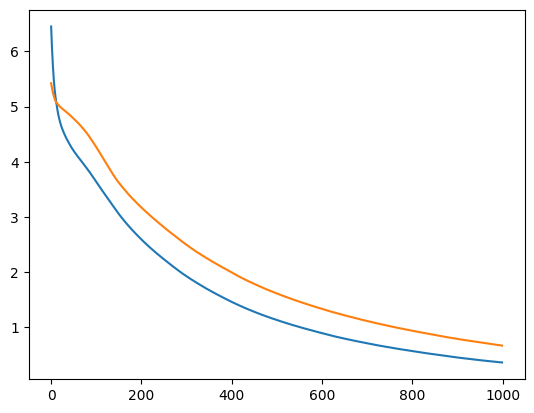

In [25]:
plt.plot(train_losses)
plt.plot(val_losses)

In [26]:
model.eval()
correct = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    labels_class = labels.argmax()
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_20029/3545108458.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [27]:
acc

0.8778468370437622

In [28]:
#(29,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.884
#(29,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.561
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.878
#(29,50), (50,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.667